# 33 · A Complete System: From Data to Performance Report

*Module 7 — Execution and Systems*

Thirty-two notebooks, each building one piece in isolation. This final notebook wires them together into a single, working, properly-engineered pipeline — and closes the course by showing that a good quantitative system is as much a software engineering achievement as a mathematical one.

## 1. Motivation

Every previous notebook in this course studied one piece of the puzzle in isolation: a feature, a model, a risk rule, a validation method. A real trading system is not a notebook that runs top to bottom once — it is a **pipeline**: data flows in one end, decisions and trades flow out the other, and every stage needs to work correctly not just on its own, but in combination with every other stage, repeatedly, reliably, and in the right order. This notebook builds that pipeline explicitly, with the specific engineering discipline — modularity, testing, logging — that separates a strategy that works in a single notebook cell from one that could plausibly be trusted to run unattended.

## 2. Intuition

Think of the pipeline as a factory assembly line, where each station does exactly one job and passes a well-defined output to the next: raw prices come in; features get computed from them; a signal gets generated from the features; a risk manager decides how large a position that signal actually justifies; an execution simulator turns that target position into realistic, cost-adjusted trades; and a reporter summarizes what happened. Each station corresponds to a concept this course already built carefully, in its own dedicated notebook — this one's job is not to invent anything new, but to enforce the discipline of keeping each stage **separate, testable, and swappable**. A well-designed pipeline lets you replace the signal-generation stage with an entirely different strategy (Module 3's momentum, Module 2's factor tilts, Module 5's ensemble model) without touching the risk management or execution code at all — and lets you write a small, fast test confirming each stage does exactly what it claims, independent of whether the *strategy* itself turns out to be any good.

## 3. Theory: architecture principles for a quant system

**Separation of concerns.** Each pipeline stage should have one clearly-defined job and know as little as possible about the others. The signal generator should not need to know how positions get sized; the execution simulator should not need to know how the signal was generated. This is what makes a system's pieces independently testable, and independently replaceable.

**Explicit data contracts.** Every stage takes a clearly-typed input and produces a clearly-typed output (here: `pandas` Series and DataFrames with well-defined columns and index alignment) — the interfaces between stages are exactly as important as the logic inside them, since a subtle index-misalignment bug between two stages is a real, common, and hard-to-notice source of look-ahead bias in a real system (recall Notebook 21's entire lesson).

**Logging, not just print statements.** A production pipeline runs unattended, often for a long time; `logging` (rather than scattered `print` calls) gives structured, timestamped, severity-tagged records of exactly what the system did and when, which is often the only way to reconstruct what happened after the fact when something eventually goes wrong.

**Unit tests for individual components.** Testing "does the whole strategy make money" is a slow, noisy, indirect way to catch a bug in one specific component. A fast, targeted test — "does the execution simulator report zero P&L for a position of exactly zero" — catches a real class of bugs immediately, in milliseconds, every time the codebase changes, long before a bug like that could quietly corrupt a full backtest's results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(name)-18s] %(levelname)s: %(message)s', datefmt='%H:%M:%S')
rng = np.random.default_rng(231)

## 4. Implementation: the pipeline, stage by stage

### 4.1 Data ingestion (Module 1's territory)

The familiar yfinance-first, calibrated-simulation-fallback pattern used throughout this course, now wrapped as a proper class with logging.

In [2]:
class DataProvider:
    """Stage 1: get a clean price series. Real source when available, calibrated simulation otherwise."""
    def __init__(self):
        self.log = logging.getLogger('DataProvider')

    def get_prices(self, ticker, start='2019-01-01', end='2025-06-30', n_days_fallback=1500, seed=0):
        import io, contextlib, logging as _logging
        try:
            import yfinance as yf
            _logging.getLogger('yfinance').setLevel(_logging.CRITICAL)
            _buf = io.StringIO()
            with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
                raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
            px = raw['Close'].dropna().squeeze()
            if len(px) < 500:
                raise RuntimeError("insufficient rows")
            self.log.info(f"Loaded {len(px)} real trading days for {ticker} via yfinance.")
            return px
        except Exception as e:
            self.log.warning(f"yfinance unavailable ({type(e).__name__}). Using a calibrated simulated series for {ticker}.")
            local_rng = np.random.default_rng(seed)
            mom_state = np.zeros(n_days_fallback)
            for t in range(1, n_days_fallback):
                mom_state[t] = 0.90 * mom_state[t-1] + local_rng.normal(0, 0.25)
            rets = 0.008 * mom_state + local_rng.normal(0, 0.011, n_days_fallback)
            idx = pd.bdate_range('2019-01-02', periods=n_days_fallback)
            prices = pd.Series(100 * np.exp(np.cumsum(rets)), index=idx)
            self.log.info(f"Generated {len(prices)} simulated trading days for {ticker}.")
            return prices

### 4.2 Feature computation (Module 5's territory)

In [3]:
class FeatureEngine:
    """Stage 2: turn raw prices into model-ready features."""
    def __init__(self):
        self.log = logging.getLogger('FeatureEngine')

    def compute_features(self, prices):
        self.log.info("Computing features (20-day momentum, 20-day realized volatility).")
        rets = prices.pct_change()
        return pd.DataFrame({
            'mom_20': rets.rolling(20).sum(),
            'vol_20': rets.rolling(20).std() * np.sqrt(252),
        })

### 4.3 Signal generation (Module 3's territory)

In [4]:
class SignalGenerator:
    """Stage 3: turn features into a directional view."""
    def __init__(self, entry_threshold=0.0):
        self.entry_threshold = entry_threshold
        self.log = logging.getLogger('SignalGenerator')

    def generate_signal(self, features):
        self.log.info(f"Generating momentum signal (threshold={self.entry_threshold}).")
        return np.sign(features['mom_20'] - self.entry_threshold)

### 4.4 Risk management and position sizing (Module 6's territory)

In [5]:
class RiskManager:
    """Stage 4: turn a directional view into an actual position size, via volatility targeting (Notebook 25)."""
    def __init__(self, target_vol=0.12, max_leverage=2.0):
        self.target_vol = target_vol
        self.max_leverage = max_leverage
        self.log = logging.getLogger('RiskManager')

    def size_position(self, signal, features):
        self.log.info(f"Sizing positions via volatility targeting (target={self.target_vol:.0%}, "
                       f"max leverage={self.max_leverage}x).")
        vol_scale = (self.target_vol / features['vol_20']).clip(upper=self.max_leverage)
        return (signal * vol_scale).shift(1)     # yesterday's information only -- no look-ahead (Notebook 21)

### 4.5 Execution simulation (Modules 1 and 28's territory)

In [6]:
class ExecutionSimulator:
    """Stage 5: turn target positions into realized, cost-adjusted P&L."""
    def __init__(self, cost_bps=5):
        self.cost_bps = cost_bps
        self.log = logging.getLogger('ExecutionSimulator')

    def simulate(self, target_positions, prices):
        self.log.info(f"Simulating execution ({self.cost_bps} bps cost per unit turnover).")
        rets = prices.pct_change().reindex(target_positions.index)
        turnover = target_positions.diff().abs().fillna(0)
        gross_pnl = target_positions.shift(1) * rets
        cost = turnover * self.cost_bps / 1e4
        return (gross_pnl - cost).dropna()

### 4.6 Performance reporting (Module 6's territory)

In [7]:
class PerformanceReporter:
    """Stage 6: summarize the resulting P&L series."""
    def __init__(self):
        self.log = logging.getLogger('PerformanceReporter')

    def generate_report(self, pnl):
        self.log.info("Generating performance report.")
        ann_ret, ann_vol = pnl.mean()*252, pnl.std()*np.sqrt(252)
        sharpe = ann_ret/ann_vol if ann_vol > 0 else np.nan
        cum = (1 + pnl).cumprod()
        max_dd = (cum/cum.cummax() - 1).min()
        calmar = ann_ret/abs(max_dd) if max_dd != 0 else np.nan
        return {'ann_return': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
                'max_drawdown': max_dd, 'calmar': calmar}

### 4.7 Unit tests for individual components

Fast, targeted, and independent of whether the overall strategy is any good -- exactly the discipline Section 3 argued for.

In [8]:
def test_execution_simulator_zero_position_gives_zero_pnl():
    es = ExecutionSimulator(cost_bps=5)
    idx = pd.bdate_range('2020-01-01', periods=10)
    positions, prices = pd.Series(0.0, index=idx), pd.Series(100.0, index=idx)
    pnl = es.simulate(positions, prices)
    assert (pnl.abs() < 1e-10).all(), "a position of exactly zero should never generate P&L, cost or otherwise"
    print("PASS: test_execution_simulator_zero_position_gives_zero_pnl")

def test_reporter_recovers_known_statistics():
    pr = PerformanceReporter()
    idx = pd.bdate_range('2020-01-01', periods=252)
    pnl = pd.Series(0.001, index=idx)                    # a constant, monotonically increasing series
    report = pr.generate_report(pnl)
    assert abs(report['ann_return'] - 0.001*252) < 1e-9, "annualized return should exactly match the constant daily rate"
    assert report['max_drawdown'] == 0, "a monotonically increasing series should show exactly zero drawdown"
    print("PASS: test_reporter_recovers_known_statistics")

def test_risk_manager_scales_down_in_high_volatility():
    rm = RiskManager(target_vol=0.12, max_leverage=2.0)
    idx = pd.bdate_range('2020-01-01', periods=3)
    signal = pd.Series([1.0, 1.0, 1.0], index=idx)
    low_vol_features = pd.DataFrame({'vol_20': [0.06, 0.06, 0.06]}, index=idx)
    high_vol_features = pd.DataFrame({'vol_20': [0.30, 0.30, 0.30]}, index=idx)
    pos_low_vol = rm.size_position(signal, low_vol_features).dropna()
    pos_high_vol = rm.size_position(signal, high_vol_features).dropna()
    assert (pos_low_vol.abs() > pos_high_vol.abs()).all(), "higher volatility should always lead to a SMALLER position"
    print("PASS: test_risk_manager_scales_down_in_high_volatility")

test_execution_simulator_zero_position_gives_zero_pnl()
test_reporter_recovers_known_statistics()
test_risk_manager_scales_down_in_high_volatility()

20:37:37 [ExecutionSimulator] INFO: Simulating execution (5 bps cost per unit turnover).


20:37:37 [PerformanceReporter] INFO: Generating performance report.


20:37:37 [RiskManager       ] INFO: Sizing positions via volatility targeting (target=12%, max leverage=2.0x).


20:37:37 [RiskManager       ] INFO: Sizing positions via volatility targeting (target=12%, max leverage=2.0x).


PASS: test_execution_simulator_zero_position_gives_zero_pnl
PASS: test_reporter_recovers_known_statistics
PASS: test_risk_manager_scales_down_in_high_volatility


### 4.8 The orchestrator: wiring every stage together

In [9]:
class TradingSystem:
    """Wires all six stages together into a single, coherent, end-to-end pipeline."""
    def __init__(self, data_provider, feature_engine, signal_generator, risk_manager, execution_simulator, reporter):
        self.data_provider = data_provider
        self.feature_engine = feature_engine
        self.signal_generator = signal_generator
        self.risk_manager = risk_manager
        self.execution_simulator = execution_simulator
        self.reporter = reporter
        self.log = logging.getLogger('TradingSystem')

    def run(self, ticker):
        self.log.info(f"=== Pipeline run starting: {ticker} ===")
        prices = self.data_provider.get_prices(ticker)
        features = self.feature_engine.compute_features(prices)
        signal = self.signal_generator.generate_signal(features)
        positions = self.risk_manager.size_position(signal, features)
        pnl = self.execution_simulator.simulate(positions, prices)
        report = self.reporter.generate_report(pnl)
        self.log.info(f"=== Pipeline run complete: Sharpe={report['sharpe']:.2f}, "
                       f"max drawdown={report['max_drawdown']:.1%} ===")
        return report, pnl, positions, prices

## 5. Worked example: running the complete system end to end

In [10]:
system = TradingSystem(
    data_provider=DataProvider(),
    feature_engine=FeatureEngine(),
    signal_generator=SignalGenerator(entry_threshold=0.0),
    risk_manager=RiskManager(target_vol=0.12, max_leverage=2.0),
    execution_simulator=ExecutionSimulator(cost_bps=5),
    reporter=PerformanceReporter(),
)

report, pnl, positions, prices = system.run('DEMO')
pd.Series(report).round(3)

20:37:37 [TradingSystem     ] INFO: === Pipeline run starting: DEMO ===


20:37:39 [DataProvider      ] WARNING: yfinance unavailable (RuntimeError). Using a calibrated simulated series for DEMO.


20:37:39 [DataProvider      ] INFO: Generated 1500 simulated trading days for DEMO.


20:37:39 [FeatureEngine     ] INFO: Computing features (20-day momentum, 20-day realized volatility).


20:37:39 [SignalGenerator   ] INFO: Generating momentum signal (threshold=0.0).


20:37:39 [RiskManager       ] INFO: Sizing positions via volatility targeting (target=12%, max leverage=2.0x).


20:37:39 [ExecutionSimulator] INFO: Simulating execution (5 bps cost per unit turnover).


20:37:39 [PerformanceReporter] INFO: Generating performance report.


20:37:39 [TradingSystem     ] INFO: === Pipeline run complete: Sharpe=1.90, max drawdown=-17.0% ===


ann_return      0.250
ann_vol         0.132
sharpe          1.896
max_drawdown   -0.170
calmar          1.469
dtype: float64

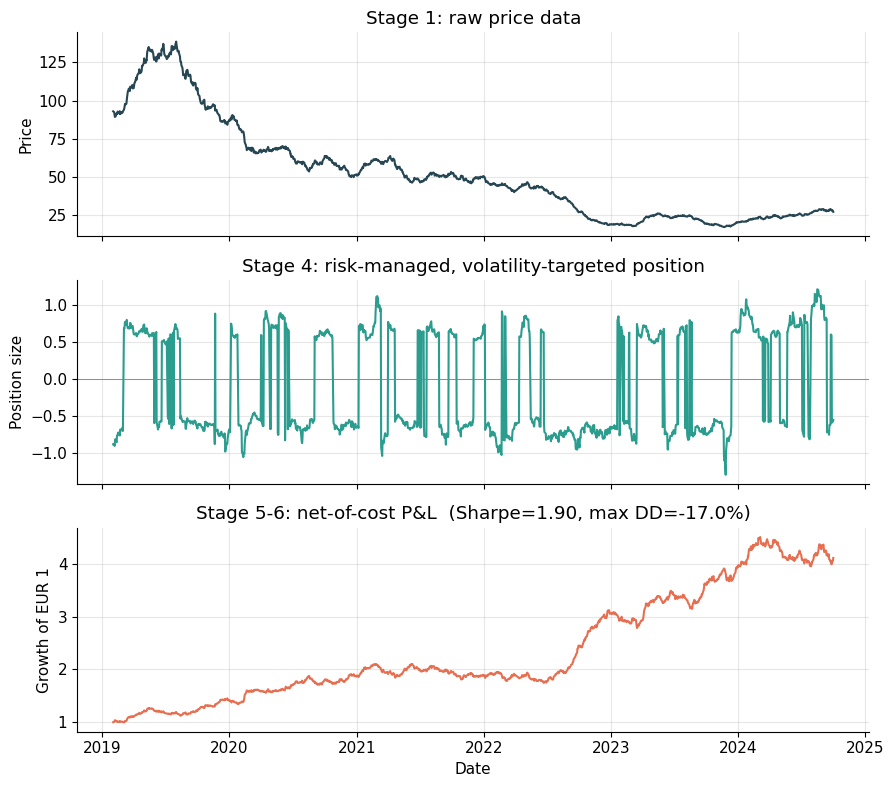

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axes[0].plot(prices.reindex(pnl.index), color='#264653')
axes[0].set_ylabel('Price')
axes[0].set_title('Stage 1: raw price data')

axes[1].plot(positions.reindex(pnl.index), color='#2a9d8f')
axes[1].axhline(0, color='gray', linewidth=0.6)
axes[1].set_ylabel('Position size')
axes[1].set_title('Stage 4: risk-managed, volatility-targeted position')

axes[2].plot((1 + pnl).cumprod(), color='#e76f51')
axes[2].set_ylabel('Growth of EUR 1')
axes[2].set_title(f"Stage 5-6: net-of-cost P&L  (Sharpe={report['sharpe']:.2f}, max DD={report['max_drawdown']:.1%})")
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

### Interpreting the result

Every number in the report above, and every line in the chart, traces back to a specific earlier notebook: the price series to Module 1's data-handling patterns, the momentum feature to Module 3 and Module 5, the volatility-targeted sizing to Notebook 25, the transaction-cost drag to Notebooks 1 and 28, and the Sharpe/Calmar summary to Notebook 26 and 29's risk-reporting vocabulary. None of the individual pieces are new; what is new, and what this whole notebook was actually about, is that they are now wired together into one system where each piece can be tested, replaced, and reasoned about independently — swap `SignalGenerator` for a completely different strategy from Module 2 or Module 5, and every other stage keeps working, unmodified, exactly as designed. **A word of caution appropriate to end the course on**: the Sharpe ratio in this particular run is unusually high for the kind of simple strategy shown here — a direct consequence of using a stylized, cleanly-detectable signal to keep this final demonstration simple and legible, not a realistic expectation for what a strategy like this would achieve on genuine market data. Module 3 and Notebook 30's data-snooping lessons apply here exactly as much as anywhere else: treat this pipeline as a template for correct *architecture*, and bring every earlier notebook's skepticism back with you before trusting any specific number it produces on a real strategy.

## 6. Limitations and pitfalls

- **This is a genuinely educational architecture, not a production one.** A real system needs persistent storage (not in-memory `pandas` objects that vanish when the process ends), proper configuration management (not hardcoded parameters), robust error handling and automatic retries for real network calls, and considerably more defensive programming around every external data source.
- **No real-time or streaming data handling.** This pipeline processes a complete, static historical series in one pass — a live system needs to handle continuously arriving data, decide when enough new information has arrived to act on, and do so within real latency constraints (Notebook 32's entire subject).
- **No portfolio-level orchestration across multiple strategies or instruments simultaneously.** This example runs one signal on one instrument; a real allocator needs to combine many strategies, manage aggregate risk across all of them at once (Module 2 and Module 6's territory), and handle capital allocation between them dynamically.
- **Minimal error handling and no monitoring/alerting beyond basic logging.** A real system needs automated checks for data quality issues, stale prices, and anomalous signal or position values, with alerts (not just log lines nobody may read in time) when something looks wrong.
- **The unit tests here check a handful of the most important properties, not exhaustive correctness.** A genuinely production-grade codebase would have substantially more test coverage, including tests for edge cases (missing data, market holidays, corporate actions) this simplified example never has to confront.

## 7. Exercises

**1. Add a new test (warm-up).**
Write one additional unit test for `FeatureEngine`: confirm that `vol_20` computed on a return series with a known, constant volatility (e.g., `rng.normal(0, 0.01, 300)`) comes out close to the expected annualized value (`0.01 * sqrt(252)`), within a reasonable tolerance. Run it alongside the existing three tests.

**2. Swap in a different signal generator.**
Implement a second signal-generating class, `MeanReversionSignal`, using a z-score-based rule in the spirit of Notebook 11 (e.g., short when price is far above its trailing moving average, long when far below), with the exact same interface (`generate_signal(features)`) as `SignalGenerator`. Confirm you can substitute it directly into the existing `TradingSystem` with no other code changes, and compare its resulting Sharpe ratio and maximum drawdown to the original momentum-based system on the same underlying data.

**3. Add a monitoring check.**
Add a `SanityChecker` stage to the pipeline that runs immediately after `RiskManager` and raises a warning (via `logging.warning`, not a hard failure) if the resulting position size ever exceeds the configured `max_leverage`, or if more than some threshold fraction of days have missing (`NaN`) positions. Wire it into `TradingSystem.run` so it executes automatically on every run, and design a deliberately broken scenario (e.g., a `RiskManager` misconfigured with an unreasonably high `max_leverage`) that triggers the warning, to confirm the check actually works before trusting it to catch a real problem later.